In [1]:
import pandas as pd
import numpy as np

In [2]:
from tqdm import tqdm
tqdm.pandas()

In [3]:
train_df = pd.read_csv("/Users/priyanshu.tuli/Desktop/machinehack/filght_distance_prediction/Dataset/Train.csv")
test_df = pd.read_csv("/Users/priyanshu.tuli/Desktop/machinehack/filght_distance_prediction/Dataset/Test.csv")

In [4]:
train_df.head()

,Origin Airport Code,Destination Airport Code,Origin Latitude,Origin Longitude,Destination Latitude,Destination Longitude,Great Circle Distance,Timezone Difference,Continent Origin,Continent Destination,Route Popularity,Flight_Distance
0,ORG754,DST883,-0.283823,-43.312707,38.508357,24.024226,8076.863942,1,South America,Europe,397,8120.606391
1,ORG301,DST627,25.954354,82.253018,40.630074,145.859627,6000.224245,11,Asia,Asia,650,5998.108994
2,ORG501,DST681,1.386828,-81.540082,1.265511,82.773779,18246.263830,9,South America,Asia,655,18207.572270
3,ORG310,DST812,23.367517,34.904649,-24.384679,121.948601,10777.984860,-2,Africa,Australia,740,10813.850260
4,ORG608,DST878,3.328282,-16.364917,40.396593,45.871911,7442.778451,-2,Africa,Asia,173,7426.288895


In [5]:
test_df.head()

,Origin Airport Code,Destination Airport Code,Origin Latitude,Origin Longitude,Destination Latitude,Destination Longitude,Great Circle Distance,Timezone Difference,Continent Origin,Continent Destination,Route Popularity,Flight_Distance
0,ORG505,DST811,23.961737,-9.132258,-11.939821,118.007422,14299.108830,4,Africa,Australia,707,NaN
1,ORG962,DST897,-31.608154,-70.013348,58.773542,-96.174442,10338.292880,-2,South America,North America,62,NaN
2,ORG250,DST735,68.182636,-57.411336,47.805394,-122.086745,4157.006160,-4,North America,North America,137,NaN
3,ORG773,DST210,61.895925,-12.118972,-17.194037,152.557524,14901.176340,-9,Europe,Australia,714,NaN
4,ORG682,DST368,35.380647,-23.815483,57.343073,136.035111,9532.806882,-4,Europe,Asia,769,NaN


In [6]:
train_df.shape

(19800, 12)

In [7]:
test_df.shape

(200, 12)

In [8]:
train_df['origin_airport_code_num'] = train_df['Origin Airport Code'].str.strip("ORG")

In [9]:
train_df['origin_airport_code_num'].nunique()

900

In [10]:
train_df['dest_airport_code_num'] = train_df['Destination Airport Code'].str.strip("DST")

In [11]:
train_df['dest_airport_code_num'].nunique()

900

In [12]:
test_df['origin_airport_code_num'] = test_df['Origin Airport Code'].str.strip("ORG")
test_df['dest_airport_code_num'] = test_df['Destination Airport Code'].str.strip("DST")

In [13]:
train_df['origin_airport_code_num'].nunique(), test_df['origin_airport_code_num'].nunique()

(900, 178)

In [14]:
train_df['dest_airport_code_num'].nunique(), test_df['dest_airport_code_num'].nunique()

(900, 179)

In [15]:
train_df['num_flights_between_origin_dest'] = train_df.groupby(['origin_airport_code_num', 'dest_airport_code_num']).transform('size')
train_df['num_flights_between_origin_dest'].unique()

array([1, 2])

In [16]:
train_df['num_flights_between_origin_dest'].head()

0    1
1    1
2    1
3    1
4    1
Name: num_flights_between_origin_dest, dtype: int64

In [17]:
train_df.head()

,Origin Airport Code,Destination Airport Code,Origin Latitude,Origin Longitude,Destination Latitude,Destination Longitude,Great Circle Distance,Timezone Difference,Continent Origin,Continent Destination,Route Popularity,Flight_Distance,origin_airport_code_num,dest_airport_code_num,num_flights_between_origin_dest
0,ORG754,DST883,-0.283823,-43.312707,38.508357,24.024226,8076.863942,1,South America,Europe,397,8120.606391,754,883,1
1,ORG301,DST627,25.954354,82.253018,40.630074,145.859627,6000.224245,11,Asia,Asia,650,5998.108994,301,627,1
2,ORG501,DST681,1.386828,-81.540082,1.265511,82.773779,18246.263830,9,South America,Asia,655,18207.572270,501,681,1
3,ORG310,DST812,23.367517,34.904649,-24.384679,121.948601,10777.984860,-2,Africa,Australia,740,10813.850260,310,812,1
4,ORG608,DST878,3.328282,-16.364917,40.396593,45.871911,7442.778451,-2,Africa,Asia,173,7426.288895,608,878,1


In [18]:
train_df['Route Popularity'].describe().round(2)

count    19800.00
mean       500.83
std        289.37
min          1.00
25%        249.00
50%        502.00
75%        751.00
max       1000.00
Name: Route Popularity, dtype: float64

In [19]:
num_chars = 10

char_index = {index: char for index, char in enumerate(np.arange(0,num_chars))}

In [20]:
char_index

{0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7, 8: 8, 9: 9}

In [21]:
origin_aiport_code_train_vectors = [np.zeros(num_chars) for i in range(len(train_df))]
dest_aiport_code_train_vectors = [np.zeros(num_chars) for i in range(len(train_df))]
origin_aiport_code_test_vectors = [np.zeros(num_chars) for i in range(len(test_df))]    
dest_aiport_code_test_vectors = [np.zeros(num_chars) for i in range(len(test_df))]

In [22]:
origin_aiport_code_train_vectors[0][0]

0.0

In [23]:
# train_df['origin_airport_code_num'] = train_df['origin_airport_code_num'].astype(str)
# test_df['origin_airport_code_num'] = test_df['origin_airport_code_num'].astype(str)
# train_df['dest_airport_code_num'] = train_df['dest_airport_code_num'].astype(str)
# test_df['dest_airport_code_num'] = test_df['dest_airport_code_num'].astype(str)

In [24]:
for i in range(len(train_df)):
    for j in range(3):
        origin_aiport_code_train_vectors[i][char_index[int(train_df['origin_airport_code_num'][i][j])]] +=1
        dest_aiport_code_train_vectors[i][char_index[int(train_df['dest_airport_code_num'][i][j])]] +=1


In [25]:
for i in range(len(test_df)):
    for j in range(3):
        origin_aiport_code_test_vectors[i][char_index[int(test_df['origin_airport_code_num'][i][j])]] +=1
        dest_aiport_code_test_vectors[i][char_index[int(test_df['dest_airport_code_num'][i][j])]] +=1

In [26]:
train_df['origin_airport_code_num'].head(5)

0    754
1    301
2    501
3    310
4    608
Name: origin_airport_code_num, dtype: object

In [27]:
origin_aiport_code_train_vectors[0]

array([0., 0., 0., 0., 1., 1., 0., 1., 0., 0.])

In [28]:
test_df['origin_airport_code_num'].head(5)

0    505
1    962
2    250
3    773
4    682
Name: origin_airport_code_num, dtype: object

In [29]:
origin_aiport_code_test_vectors[0]

array([1., 0., 0., 0., 0., 2., 0., 0., 0., 0.])

In [30]:
origin_aiport_code_train_vectors_df = pd.DataFrame(origin_aiport_code_train_vectors, columns=['origin_airport_code_num_{0}'.format(i) for i in range(num_chars)])
dest_aiport_code_train_vectors_df = pd.DataFrame(dest_aiport_code_train_vectors, columns=['dest_airport_code_num_{0}'.format(i) for i in range(num_chars)])
origin_aiport_code_test_vectors_df = pd.DataFrame(origin_aiport_code_test_vectors, columns=['origin_airport_code_num_{0}'.format(i) for i in range(num_chars)])
dest_aiport_code_test_vectors_df = pd.DataFrame(dest_aiport_code_test_vectors, columns=['dest_airport_code_num_{0}'.format(i) for i in range(num_chars)])

In [31]:
origin_aiport_code_test_vectors_df.shape, dest_aiport_code_test_vectors_df.shape, origin_aiport_code_train_vectors_df.shape, dest_aiport_code_train_vectors_df.shape

((200, 10), (200, 10), (19800, 10), (19800, 10))

In [32]:
origin_aiport_code_train_vectors_df.head()

,origin_airport_code_num_0,origin_airport_code_num_1,origin_airport_code_num_2,origin_airport_code_num_3,origin_airport_code_num_4,origin_airport_code_num_5,origin_airport_code_num_6,origin_airport_code_num_7,origin_airport_code_num_8,origin_airport_code_num_9
0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0
1,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [33]:
origin_aiport_code_test_vectors_df.head()

,origin_airport_code_num_0,origin_airport_code_num_1,origin_airport_code_num_2,origin_airport_code_num_3,origin_airport_code_num_4,origin_airport_code_num_5,origin_airport_code_num_6,origin_airport_code_num_7,origin_airport_code_num_8,origin_airport_code_num_9
0,1.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0
1,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0,0.0,0.0
4,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [34]:
origin_aiport_code_train_vectors_df = origin_aiport_code_train_vectors_df.astype(int)
dest_aiport_code_train_vectors_df = dest_aiport_code_train_vectors_df.astype(int)
origin_aiport_code_test_vectors_df = origin_aiport_code_test_vectors_df.astype(int)
dest_aiport_code_test_vectors_df = dest_aiport_code_test_vectors_df.astype(int)

In [35]:
train_df.shape, test_df.shape

((19800, 15), (200, 14))

In [36]:
origin_aiport_code_test_vectors_df.shape, dest_aiport_code_test_vectors_df.shape, origin_aiport_code_train_vectors_df.shape, dest_aiport_code_train_vectors_df.shape

((200, 10), (200, 10), (19800, 10), (19800, 10))

In [37]:
new_train_df = pd.concat([train_df, origin_aiport_code_train_vectors_df, dest_aiport_code_train_vectors_df], axis=1, ignore_index=True)
new_test_df = pd.concat([test_df, origin_aiport_code_test_vectors_df, dest_aiport_code_test_vectors_df], axis=1, ignore_index=True)

In [38]:
new_train_df.columns = train_df.columns.tolist() + origin_aiport_code_train_vectors_df.columns.tolist() + dest_aiport_code_train_vectors_df.columns.tolist()
new_test_df.columns = test_df.columns.tolist() + origin_aiport_code_test_vectors_df.columns.tolist() + dest_aiport_code_test_vectors_df.columns.tolist()

In [39]:
train_df = new_train_df.copy()
test_df = new_test_df.copy()

In [40]:
train_df.head()

,Origin Airport Code,Destination Airport Code,Origin Latitude,Origin Longitude,Destination Latitude,Destination Longitude,Great Circle Distance,Timezone Difference,Continent Origin,Continent Destination,...,dest_airport_code_num_0,dest_airport_code_num_1,dest_airport_code_num_2,dest_airport_code_num_3,dest_airport_code_num_4,dest_airport_code_num_5,dest_airport_code_num_6,dest_airport_code_num_7,dest_airport_code_num_8,dest_airport_code_num_9
0,ORG754,DST883,-0.283823,-43.312707,38.508357,24.024226,8076.863942,1,South America,Europe,...,0,0,0,1,0,0,0,0,2,0
1,ORG301,DST627,25.954354,82.253018,40.630074,145.859627,6000.224245,11,Asia,Asia,...,0,0,1,0,0,0,1,1,0,0
2,ORG501,DST681,1.386828,-81.540082,1.265511,82.773779,18246.263830,9,South America,Asia,...,0,1,0,0,0,0,1,0,1,0
3,ORG310,DST812,23.367517,34.904649,-24.384679,121.948601,10777.984860,-2,Africa,Australia,...,0,1,1,0,0,0,0,0,1,0
4,ORG608,DST878,3.328282,-16.364917,40.396593,45.871911,7442.778451,-2,Africa,Asia,...,0,0,0,0,0,0,0,1,2,0


In [41]:
origin_aiport_code_train_vectors_df.shape, dest_aiport_code_train_vectors_df.shape

((19800, 10), (19800, 10))

In [42]:
origin_aiport_code_test_vectors_df.shape, dest_aiport_code_test_vectors_df.shape

((200, 10), (200, 10))

In [43]:
train_df.shape, test_df.shape

((19800, 35), (200, 34))

In [44]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [45]:
train_df.head()

,Origin Airport Code,Destination Airport Code,Origin Latitude,Origin Longitude,Destination Latitude,Destination Longitude,Great Circle Distance,Timezone Difference,Continent Origin,Continent Destination,Route Popularity,Flight_Distance,origin_airport_code_num,dest_airport_code_num,num_flights_between_origin_dest,origin_airport_code_num_0,origin_airport_code_num_1,origin_airport_code_num_2,origin_airport_code_num_3,origin_airport_code_num_4,origin_airport_code_num_5,origin_airport_code_num_6,origin_airport_code_num_7,origin_airport_code_num_8,origin_airport_code_num_9,dest_airport_code_num_0,dest_airport_code_num_1,dest_airport_code_num_2,dest_airport_code_num_3,dest_airport_code_num_4,dest_airport_code_num_5,dest_airport_code_num_6,dest_airport_code_num_7,dest_airport_code_num_8,dest_airport_code_num_9
0,ORG754,DST883,-0.283823,-43.312707,38.508357,24.024226,8076.863942,1,South America,Europe,397,8120.606391,754,883,1,0,0,0,0,1,1,0,1,0,0,0,0,0,1,0,0,0,0,2,0
1,ORG301,DST627,25.954354,82.253018,40.630074,145.859627,6000.224245,11,Asia,Asia,650,5998.108994,301,627,1,1,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,1,0,0
2,ORG501,DST681,1.386828,-81.540082,1.265511,82.773779,18246.263830,9,South America,Asia,655,18207.572270,501,681,1,1,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,1,0
3,ORG310,DST812,23.367517,34.904649,-24.384679,121.948601,10777.984860,-2,Africa,Australia,740,10813.850260,310,812,1,1,1,0,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,0
4,ORG608,DST878,3.328282,-16.364917,40.396593,45.871911,7442.778451,-2,Africa,Asia,173,7426.288895,608,878,1,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,2,0


In [46]:
train_df['is_flight_east_of_origin'] = train_df['Timezone Difference'].apply(lambda x: 1 if x > 0 else 0)

In [47]:
train_df['is_flight_east_of_origin'].value_counts(normalize=True)

is_flight_east_of_origin
0    0.521667
1    0.478333
Name: proportion, dtype: float64

In [48]:
test_df['is_flight_east_of_origin'] = test_df['Timezone Difference'].apply(lambda x: 1 if x > 0 else 0)

In [49]:
test_df['is_flight_east_of_origin'].value_counts(normalize=True)

is_flight_east_of_origin
1    0.52
0    0.48
Name: proportion, dtype: float64

In [50]:
train_df.head()

,Origin Airport Code,Destination Airport Code,Origin Latitude,Origin Longitude,Destination Latitude,Destination Longitude,Great Circle Distance,Timezone Difference,Continent Origin,Continent Destination,Route Popularity,Flight_Distance,origin_airport_code_num,dest_airport_code_num,num_flights_between_origin_dest,origin_airport_code_num_0,origin_airport_code_num_1,origin_airport_code_num_2,origin_airport_code_num_3,origin_airport_code_num_4,origin_airport_code_num_5,origin_airport_code_num_6,origin_airport_code_num_7,origin_airport_code_num_8,origin_airport_code_num_9,dest_airport_code_num_0,dest_airport_code_num_1,dest_airport_code_num_2,dest_airport_code_num_3,dest_airport_code_num_4,dest_airport_code_num_5,dest_airport_code_num_6,dest_airport_code_num_7,dest_airport_code_num_8,dest_airport_code_num_9,is_flight_east_of_origin
0,ORG754,DST883,-0.283823,-43.312707,38.508357,24.024226,8076.863942,1,South America,Europe,397,8120.606391,754,883,1,0,0,0,0,1,1,0,1,0,0,0,0,0,1,0,0,0,0,2,0,1
1,ORG301,DST627,25.954354,82.253018,40.630074,145.859627,6000.224245,11,Asia,Asia,650,5998.108994,301,627,1,1,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,1,0,0,1
2,ORG501,DST681,1.386828,-81.540082,1.265511,82.773779,18246.263830,9,South America,Asia,655,18207.572270,501,681,1,1,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,1,0,1
3,ORG310,DST812,23.367517,34.904649,-24.384679,121.948601,10777.984860,-2,Africa,Australia,740,10813.850260,310,812,1,1,1,0,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,0,0
4,ORG608,DST878,3.328282,-16.364917,40.396593,45.871911,7442.778451,-2,Africa,Asia,173,7426.288895,608,878,1,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,2,0,0


In [52]:
train_df['median_flight_distance_from_org_to_dest_airport'] = train_df.groupby(['origin_airport_code_num', 'dest_airport_code_num'])['Flight_Distance'].transform('median')
train_df['std_flight_distance_from_org_to_dest_airport'] = train_df.groupby(['origin_airport_code_num', 'dest_airport_code_num'])['Flight_Distance'].transform('std')
train_df['min_flight_distance_from_org_to_dest_airport'] = train_df.groupby(['origin_airport_code_num', 'dest_airport_code_num'])['Flight_Distance'].transform('min')
train_df['max_flight_distance_from_org_to_dest_airport'] = train_df.groupby(['origin_airport_code_num', 'dest_airport_code_num'])['Flight_Distance'].transform('max')
train_df['mean_flight_distance_from_org_to_dest_airport'] = train_df.groupby(['origin_airport_code_num', 'dest_airport_code_num'])['Flight_Distance'].transform('mean')

In [56]:
median_flight_distance_from_org_to_dest_airport_mapping = train_df[['origin_airport_code_num', 'dest_airport_code_num', 'median_flight_distance_from_org_to_dest_airport']].drop_duplicates(subset=['origin_airport_code_num', 'dest_airport_code_num'], keep='first').set_index(['origin_airport_code_num', 'dest_airport_code_num'])['median_flight_distance_from_org_to_dest_airport'].to_dict()
std_flight_distance_from_org_to_dest_airport_mapping = train_df[['origin_airport_code_num', 'dest_airport_code_num', 'std_flight_distance_from_org_to_dest_airport']].drop_duplicates(subset=['origin_airport_code_num', 'dest_airport_code_num'], keep='first').set_index(['origin_airport_code_num', 'dest_airport_code_num'])['std_flight_distance_from_org_to_dest_airport'].to_dict()
min_flight_distance_from_org_to_dest_airport_mapping = train_df[['origin_airport_code_num', 'dest_airport_code_num', 'min_flight_distance_from_org_to_dest_airport']].drop_duplicates(subset=['origin_airport_code_num', 'dest_airport_code_num'], keep='first').set_index(['origin_airport_code_num', 'dest_airport_code_num'])['min_flight_distance_from_org_to_dest_airport'].to_dict()
max_flight_distance_from_org_to_dest_airport_mapping = train_df[['origin_airport_code_num', 'dest_airport_code_num', 'max_flight_distance_from_org_to_dest_airport']].drop_duplicates(subset=['origin_airport_code_num', 'dest_airport_code_num'], keep='first').set_index(['origin_airport_code_num', 'dest_airport_code_num'])['max_flight_distance_from_org_to_dest_airport'].to_dict()
mean_flight_distance_from_org_to_dest_airport_mapping = train_df[['origin_airport_code_num', 'dest_airport_code_num', 'mean_flight_distance_from_org_to_dest_airport']].drop_duplicates(subset=['origin_airport_code_num', 'dest_airport_code_num'], keep='first').set_index(['origin_airport_code_num', 'dest_airport_code_num'])['mean_flight_distance_from_org_to_dest_airport'].to_dict()

In [57]:
test_df['median_flight_distance_from_org_to_dest_airport'] = test_df.apply(lambda x: median_flight_distance_from_org_to_dest_airport_mapping.get((x['origin_airport_code_num'], x['dest_airport_code_num']), np.nan), axis=1)
test_df['std_flight_distance_from_org_to_dest_airport'] = test_df.apply(lambda x: std_flight_distance_from_org_to_dest_airport_mapping.get((x['origin_airport_code_num'], x['dest_airport_code_num']), np.nan), axis=1)
test_df['min_flight_distance_from_org_to_dest_airport'] = test_df.apply(lambda x: min_flight_distance_from_org_to_dest_airport_mapping.get((x['origin_airport_code_num'], x['dest_airport_code_num']), np.nan), axis=1)
test_df['max_flight_distance_from_org_to_dest_airport'] = test_df.apply(lambda x: max_flight_distance_from_org_to_dest_airport_mapping.get((x['origin_airport_code_num'], x['dest_airport_code_num']), np.nan), axis=1)
test_df['mean_flight_distance_from_org_to_dest_airport'] = test_df.apply(lambda x: mean_flight_distance_from_org_to_dest_airport_mapping.get((x['origin_airport_code_num'], x['dest_airport_code_num']), np.nan), axis=1)

In [58]:
test_df['median_flight_distance_from_org_to_dest_airport'].describe().round(2), train_df['median_flight_distance_from_org_to_dest_airport'].describe().round(2)

(count        5.00
 mean     14405.81
 std       3856.83
 min       9371.86
 25%      11111.40
 50%      17005.18
 75%      17006.23
 max      17534.40
 Name: median_flight_distance_from_org_to_dest_airport, dtype: float64,
 count    19800.00
 mean      9381.83
 std       4442.22
 min         12.37
 25%       5947.85
 50%       9488.30
 75%      12770.16
 max      19963.92
 Name: median_flight_distance_from_org_to_dest_airport, dtype: float64)

In [ ]:
origin_airport_freq = train_df['origin_airport_code_num'].value_counts(normalize=True)
dest_airport_freq = train_df['dest_airport_code_num'].value_counts(normalize=True)

In [67]:
origin_airport_freq.head()

origin_airport_code_num
380    0.001818
479    0.001818
324    0.001768
782    0.001717
429    0.001717
Name: proportion, dtype: float64

In [68]:
train_df['origin_airport_code_num_freq'] = train_df['origin_airport_code_num'].map(origin_airport_freq)

In [70]:
train_df['dest_airport_code_num_freq'] = train_df['dest_airport_code_num'].map(dest_airport_freq)

In [72]:
train_df['origin_airport_code_num_freq'].describe().round(4)

count    19800.0000
mean         0.0012
std          0.0002
min          0.0004
25%          0.0010
50%          0.0012
75%          0.0013
max          0.0018
Name: origin_airport_code_num_freq, dtype: float64

In [73]:
train_df['dest_airport_code_num_freq'].describe().round(4)

count    19800.0000
mean         0.0012
std          0.0002
min          0.0004
25%          0.0010
50%          0.0012
75%          0.0013
max          0.0019
Name: dest_airport_code_num_freq, dtype: float64

In [74]:
test_df['origin_airport_code_num_freq'] = test_df['origin_airport_code_num'].map(origin_airport_freq)
test_df['dest_airport_code_num_freq'] = test_df['dest_airport_code_num'].map(dest_airport_freq)

In [75]:
origin_connectivity = train_df.groupby('origin_airport_code_num')['dest_airport_code_num'].nunique()
origin_connectivity.head()

origin_airport_code_num
100    25
101    18
102    20
103    16
104    16
Name: dest_airport_code_num, dtype: int64

In [76]:
dest_connectivity = train_df.groupby('dest_airport_code_num')['origin_airport_code_num'].nunique()
dest_connectivity.head()

dest_airport_code_num
100    15
101    18
102    30
103    16
104    23
Name: origin_airport_code_num, dtype: int64

In [77]:
train_df['origin_airport_code_num_connectivity'] = train_df['origin_airport_code_num'].map(origin_connectivity)
train_df['dest_airport_code_num_connectivity'] = train_df['dest_airport_code_num'].map(dest_connectivity)
train_df['origin_airport_code_num_connectivity'].describe().round(4)

count    19800.0000
mean        22.6974
std          4.4709
min          8.0000
25%         20.0000
50%         23.0000
75%         26.0000
max         36.0000
Name: origin_airport_code_num_connectivity, dtype: float64

In [78]:
test_df['origin_airport_code_num_connectivity'] = test_df['origin_airport_code_num'].map(origin_connectivity)
test_df['dest_airport_code_num_connectivity'] = test_df['dest_airport_code_num'].map(dest_connectivity)

In [79]:
from haversine import haversine, Unit

In [80]:
train_df['haversine_distance_between_airports'] = train_df.progress_apply(lambda x: haversine((x['Origin Latitude'], x['Origin Longitude']), (x['Destination Latitude'], x['Destination Longitude']), unit=Unit.MILES), axis=1)
test_df['haversine_distance_between_airports'] = test_df.progress_apply(lambda x: haversine((x['Origin Latitude'], x['Origin Longitude']), (x['Destination Latitude'], x['Destination Longitude']), unit=Unit.MILES), axis=1)

100%|██████████| 200/200 [00:00<00:00, 84197.61it/s]


In [81]:
train_df['haversine_distance_between_airports'].describe().round(2)

count    19800.00
mean      5829.67
std       2774.74
min         17.31
25%       3679.45
50%       5896.54
75%       7947.24
max      12375.25
Name: haversine_distance_between_airports, dtype: float64

In [82]:
train_df['Great Circle Distance'].describe().round(2)

count    19800.00
mean      9381.93
std       4465.51
min         27.85
25%       5921.50
50%       9489.55
75%      12789.83
max      19916.01
Name: Great Circle Distance, dtype: float64

In [83]:
test_df['haversine_distance_between_airports'].describe().round(2)

count      200.00
mean      5846.59
std       2745.81
min        443.83
25%       3816.47
50%       6067.35
75%       7642.30
max      11900.65
Name: haversine_distance_between_airports, dtype: float64

In [84]:
test_df['Great Circle Distance'].describe().round(2)

count      200.00
mean      9409.16
std       4418.95
min        714.27
25%       6142.00
50%       9764.44
75%      12299.07
max      19152.21
Name: Great Circle Distance, dtype: float64

In [85]:
from sklearn.preprocessing import OneHotEncoder

In [86]:
ohe = OneHotEncoder(handle_unknown='ignore')

In [87]:
continent_ohe = ohe.fit(train_df[['Continent Origin', 'Continent Destination']])

In [88]:
train_df_ohe = pd.DataFrame(continent_ohe.transform(train_df[['Continent Origin', 'Continent Destination']]).toarray(), columns=continent_ohe.get_feature_names_out(['Continent Origin', 'Continent Destination']))
test_df_ohe = pd.DataFrame(continent_ohe.transform(test_df[['Continent Origin', 'Continent Destination']]).toarray(), columns=continent_ohe.get_feature_names_out(['Continent Origin', 'Continent Destination']))

In [89]:
train_df_ohe.shape, test_df_ohe.shape

((19800, 12), (200, 12))

In [90]:
train_df_ohe.head()

,Continent Origin_Africa,Continent Origin_Asia,Continent Origin_Australia,Continent Origin_Europe,Continent Origin_North America,Continent Origin_South America,Continent Destination_Africa,Continent Destination_Asia,Continent Destination_Australia,Continent Destination_Europe,Continent Destination_North America,Continent Destination_South America
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [91]:
train_df_ohe = train_df_ohe.astype(int)
test_df_ohe = test_df_ohe.astype(int)

In [92]:
new_train_df = pd.concat([train_df, train_df_ohe], axis=1, ignore_index=True)
new_test_df = pd.concat([test_df, test_df_ohe], axis=1, ignore_index=True)
new_train_df.columns = train_df.columns.tolist() + train_df_ohe.columns.tolist()
new_test_df.columns = test_df.columns.tolist() + test_df_ohe.columns.tolist()
train_df = new_train_df.copy()
test_df = new_test_df.copy()

In [93]:
train_df.head()

,Origin Airport Code,Destination Airport Code,Origin Latitude,Origin Longitude,Destination Latitude,Destination Longitude,Great Circle Distance,Timezone Difference,Continent Origin,Continent Destination,Route Popularity,Flight_Distance,origin_airport_code_num,dest_airport_code_num,num_flights_between_origin_dest,origin_airport_code_num_0,origin_airport_code_num_1,origin_airport_code_num_2,origin_airport_code_num_3,origin_airport_code_num_4,origin_airport_code_num_5,origin_airport_code_num_6,origin_airport_code_num_7,origin_airport_code_num_8,origin_airport_code_num_9,dest_airport_code_num_0,dest_airport_code_num_1,dest_airport_code_num_2,dest_airport_code_num_3,dest_airport_code_num_4,dest_airport_code_num_5,dest_airport_code_num_6,dest_airport_code_num_7,dest_airport_code_num_8,dest_airport_code_num_9,is_flight_east_of_origin,median_flight_distance_from_org_to_dest_airport,std_flight_distance_from_org_to_dest_airport,min_flight_distance_from_org_to_dest_airport,max_flight_distance_from_org_to_dest_airport,mean_flight_distance_from_org_to_dest_airport,origin_airport_code_num_freq,dest_airport_code_num_freq,origin_airport_code_num_connectivity,dest_airport_code_num_connectivity,haversine_distance_between_airports,Continent Origin_Africa,Continent Origin_Asia,Continent Origin_Australia,Continent Origin_Europe,Continent Origin_North America,Continent Origin_South America,Continent Destination_Africa,Continent Destination_Asia,Continent Destination_Australia,Continent Destination_Europe,Continent Destination_North America,Continent Destination_South America
0,ORG754,DST883,-0.283823,-43.312707,38.508357,24.024226,8076.863942,1,South America,Europe,397,8120.606391,754,883,1,0,0,0,0,1,1,0,1,0,0,0,0,0,1,0,0,0,0,2,0,1,8120.606391,NaN,8120.606391,8120.606391,8120.606391,0.000960,0.000707,19,14,5018.737507,0,0,0,0,0,1,0,0,0,1,0,0
1,ORG301,DST627,25.954354,82.253018,40.630074,145.859627,6000.224245,11,Asia,Asia,650,5998.108994,301,627,1,1,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,1,0,0,1,5998.108994,NaN,5998.108994,5998.108994,5998.108994,0.001111,0.001263,20,25,3728.371641,0,1,0,0,0,0,0,1,0,0,0,0
2,ORG501,DST681,1.386828,-81.540082,1.265511,82.773779,18246.263830,9,South America,Asia,655,18207.572270,501,681,1,1,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,1,0,1,18207.572270,NaN,18207.572270,18207.572270,18207.572270,0.000808,0.001465,16,29,11337.718368,0,0,0,0,0,1,0,1,0,0,0,0
3,ORG310,DST812,23.367517,34.904649,-24.384679,121.948601,10777.984860,-2,Africa,Australia,740,10813.850260,310,812,1,1,1,0,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,0,0,10813.850260,NaN,10813.850260,10813.850260,10813.850260,0.000960,0.001515,19,29,6697.138551,1,0,0,0,0,0,0,0,1,0,0,0
4,ORG608,DST878,3.328282,-16.364917,40.396593,45.871911,7442.778451,-2,Africa,Asia,173,7426.288895,608,878,1,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,2,0,0,7426.288895,NaN,7426.288895,7426.288895,7426.288895,0.001162,0.001162,23,23,4624.734506,1,0,0,0,0,0,0,1,0,0,0,0


In [94]:
route_popularity_quantile = train_df['Route Popularity'].quantile([0.25, 0.5, 0.75])

In [95]:
train_df['route_popularity_category'] = pd.cut(train_df['Route Popularity'], bins=[-1, route_popularity_quantile[0.25], route_popularity_quantile[0.5], route_popularity_quantile[0.75], train_df['Route Popularity'].max()], labels=['low', 'medium', 'high', 'very high'])
train_df['route_popularity_category'].value_counts(normalize=True)

route_popularity_category
high         0.250455
medium       0.250202
low          0.250101
very high    0.249242
Name: proportion, dtype: float64

In [96]:
test_df['route_popularity_category'] = pd.cut(test_df['Route Popularity'], bins=[-1, route_popularity_quantile[0.25], route_popularity_quantile[0.5], route_popularity_quantile[0.75], test_df['Route Popularity'].max()], labels=['low', 'medium', 'high', 'very high'])

In [97]:
test_df['route_popularity_category'].value_counts(normalize=True)

route_popularity_category
very high    0.265
high         0.255
low          0.250
medium       0.230
Name: proportion, dtype: float64

In [98]:
train_df['route_popularity_category_encoded'] = train_df['route_popularity_category'].map({'low': 0, 'medium': 1, 'high': 2, 'very high': 3})
train_df['route_popularity_category_encoded'].value_counts(normalize=True)

route_popularity_category_encoded
2    0.250455
1    0.250202
0    0.250101
3    0.249242
Name: proportion, dtype: float64

In [99]:
test_df['route_popularity_category_encoded'] = test_df['route_popularity_category'].map({'low': 0, 'medium': 1, 'high': 2, 'very high': 3})
test_df['route_popularity_category_encoded'].value_counts(normalize=True)

route_popularity_category_encoded
3    0.265
2    0.255
0    0.250
1    0.230
Name: proportion, dtype: float64

In [100]:
train_df['is_origin_dest_same_continent'] = np.where(train_df['Continent Origin'] == train_df['Continent Destination'], 1, 0)
train_df['is_origin_dest_same_continent'].value_counts(normalize=True)

is_origin_dest_same_continent
0    0.828384
1    0.171616
Name: proportion, dtype: float64

In [101]:
test_df['is_origin_dest_same_continent'] = np.where(test_df['Continent Origin'] == test_df['Continent Destination'], 1, 0)
test_df['is_origin_dest_same_continent'].value_counts(normalize=True)

is_origin_dest_same_continent
0    0.81
1    0.19
Name: proportion, dtype: float64

In [102]:
import xgboost as xgb

In [103]:
train_df.columns = train_df.columns.str.replace(' ', '_')
test_df.columns = test_df.columns.str.replace(' ', '_')

In [104]:
train_df.columns

Index(['Origin_Airport_Code', 'Destination_Airport_Code', 'Origin_Latitude',
       'Origin_Longitude', 'Destination_Latitude', 'Destination_Longitude',
       'Great_Circle_Distance', 'Timezone_Difference', 'Continent_Origin',
       'Continent_Destination', 'Route_Popularity', 'Flight_Distance',
       'origin_airport_code_num', 'dest_airport_code_num',
       'num_flights_between_origin_dest', 'origin_airport_code_num_0',
       'origin_airport_code_num_1', 'origin_airport_code_num_2',
       'origin_airport_code_num_3', 'origin_airport_code_num_4',
       'origin_airport_code_num_5', 'origin_airport_code_num_6',
       'origin_airport_code_num_7', 'origin_airport_code_num_8',
       'origin_airport_code_num_9', 'dest_airport_code_num_0',
       'dest_airport_code_num_1', 'dest_airport_code_num_2',
       'dest_airport_code_num_3', 'dest_airport_code_num_4',
       'dest_airport_code_num_5', 'dest_airport_code_num_6',
       'dest_airport_code_num_7', 'dest_airport_code_num_8',
    

In [105]:
feature_to_use = ['Origin_Latitude',
       'Origin_Longitude', 'Destination_Latitude', 'Destination_Longitude',
       'Great_Circle_Distance', 'Timezone_Difference', 'Route_Popularity',
       'origin_airport_code_num_0',
       'origin_airport_code_num_1', 'origin_airport_code_num_2',
       'origin_airport_code_num_3', 'origin_airport_code_num_4',
       'origin_airport_code_num_5', 'origin_airport_code_num_6',
       'origin_airport_code_num_7', 'origin_airport_code_num_8',
       'origin_airport_code_num_9', 'dest_airport_code_num_0',
       'dest_airport_code_num_1', 'dest_airport_code_num_2',
       'dest_airport_code_num_3', 'dest_airport_code_num_4',
       'dest_airport_code_num_5', 'dest_airport_code_num_6',
       'dest_airport_code_num_7', 'dest_airport_code_num_8',
       'dest_airport_code_num_9', 'is_flight_east_of_origin',
       'haversine_distance_between_airports', 'Continent_Origin_Africa',
       'Continent_Origin_Asia', 'Continent_Origin_Australia',
       'Continent_Origin_Europe', 'Continent_Origin_North_America',
       'Continent_Origin_South_America', 'Continent_Destination_Africa',
       'Continent_Destination_Asia', 'Continent_Destination_Australia',
       'Continent_Destination_Europe', 'Continent_Destination_North_America',
       'Continent_Destination_South_America',
       'route_popularity_category_encoded',
       'is_origin_dest_same_continent',
       'median_flight_distance_from_org_to_dest_airport',
       'std_flight_distance_from_org_to_dest_airport',
       'min_flight_distance_from_org_to_dest_airport',
       'max_flight_distance_from_org_to_dest_airport',
       'mean_flight_distance_from_org_to_dest_airport',
       'origin_airport_code_num_freq', 'dest_airport_code_num_freq',
       'origin_airport_code_num_connectivity',
       'dest_airport_code_num_connectivity']

In [106]:
train_df[feature_to_use].corr().round(2)

,Origin_Latitude,Origin_Longitude,Destination_Latitude,Destination_Longitude,Great_Circle_Distance,Timezone_Difference,Route_Popularity,origin_airport_code_num_0,origin_airport_code_num_1,origin_airport_code_num_2,origin_airport_code_num_3,origin_airport_code_num_4,origin_airport_code_num_5,origin_airport_code_num_6,origin_airport_code_num_7,origin_airport_code_num_8,origin_airport_code_num_9,dest_airport_code_num_0,dest_airport_code_num_1,dest_airport_code_num_2,dest_airport_code_num_3,dest_airport_code_num_4,dest_airport_code_num_5,dest_airport_code_num_6,dest_airport_code_num_7,dest_airport_code_num_8,dest_airport_code_num_9,is_flight_east_of_origin,haversine_distance_between_airports,Continent_Origin_Africa,Continent_Origin_Asia,Continent_Origin_Australia,Continent_Origin_Europe,Continent_Origin_North_America,Continent_Origin_South_America,Continent_Destination_Africa,Continent_Destination_Asia,Continent_Destination_Australia,Continent_Destination_Europe,Continent_Destination_North_America,Continent_Destination_South_America,route_popularity_category_encoded,is_origin_dest_same_continent,median_flight_distance_from_org_to_dest_airport,std_flight_distance_from_org_to_dest_airport,min_flight_distance_from_org_to_dest_airport,max_flight_distance_from_org_to_dest_airport,mean_flight_distance_from_org_to_dest_airport,origin_airport_code_num_freq,dest_airport_code_num_freq,origin_airport_code_num_connectivity,dest_airport_code_num_connectivity
Origin_Latitude,1.00,-0.27,0.01,-0.00,-0.17,-0.02,0.01,-0.01,0.00,0.00,0.00,-0.01,0.00,0.00,0.00,0.00,-0.00,-0.02,0.00,0.01,0.00,0.01,0.00,-0.01,0.00,-0.01,-0.00,-0.01,-0.17,-0.17,0.22,-0.52,0.51,0.38,-0.43,0.01,0.00,-0.01,0.01,-0.00,-0.01,0.01,-0.00,-0.16,0.00,-0.16,-0.16,-0.16,0.01,0.00,0.01,0.00
Origin_Longitude,-0.27,1.00,-0.00,0.02,0.02,0.01,-0.00,-0.00,0.01,-0.01,-0.00,0.00,0.00,0.02,-0.02,0.00,-0.01,0.01,0.00,0.01,-0.01,0.00,-0.01,-0.00,-0.00,-0.01,0.00,0.00,0.02,0.01,0.41,0.61,-0.01,-0.65,-0.37,-0.00,0.01,0.01,-0.00,-0.01,-0.01,0.00,0.00,0.02,0.03,0.02,0.02,0.02,-0.01,-0.00,-0.01,-0.00
Destination_Latitude,0.01,-0.00,1.00,-0.29,-0.17,-0.01,-0.00,0.00,-0.01,-0.00,-0.00,0.01,-0.00,-0.01,-0.00,0.00,0.01,0.01,-0.00,-0.01,0.01,0.00,-0.00,-0.01,-0.00,0.01,-0.00,-0.01,-0.17,-0.02,-0.00,0.00,0.01,0.01,-0.01,-0.16,0.22,-0.53,0.51,0.39,-0.42,-0.00,0.00,-0.17,0.03,-0.17,-0.17,-0.17,0.01,-0.00,0.01,-0.00
Destination_Longitude,-0.00,0.02,-0.29,1.00,0.03,0.01,-0.01,-0.00,-0.00,-0.00,-0.00,-0.01,-0.00,0.00,0.01,0.01,0.01,-0.00,0.00,0.00,-0.01,0.00,-0.00,0.01,-0.02,0.01,0.00,0.01,0.03,-0.00,0.01,0.01,0.00,-0.02,-0.00,0.01,0.41,0.62,-0.02,-0.65,-0.37,-0.00,-0.00,0.03,0.05,0.03,0.03,0.03,0.01,0.01,0.01,0.01
Great_Circle_Distance,-0.17,0.02,-0.17,0.03,1.00,0.01,0.01,0.00,-0.00,-0.00,0.00,-0.01,0.01,-0.01,0.00,0.01,-0.00,0.01,-0.00,-0.01,0.00,-0.00,0.01,0.00,-0.01,-0.01,0.01,0.00,1.00,-0.05,-0.04,0.13,-0.14,0.02,0.08,-0.06,-0.04,0.14,-0.13,0.01,0.07,0.01,-0.61,0.99,-0.05,0.99,0.99,0.99,-0.01,0.00,-0.01,0.00
Timezone_Difference,-0.02,0.01,-0.01,0.01,0.01,1.00,0.01,0.00,0.00,0.00,0.00,-0.00,-0.01,0.00,0.00,-0.00,-0.00,0.01,-0.00,-0.01,0.00,0.00,-0.00,0.01,0.00,0.00,-0.00,0.87,0.01,0.01,0.01,-0.00,-0.02,-0.01,0.01,0.00,0.00,0.01,-0.00,-0.01,0.00,0.00,-0.00,0.01,0.04,0.01,0.01,0.01,0.00,0.01,0.00,0.01
Route_Popularity,0.01,-0.00,-0.00,-0.01,0.01,0.01,1.00,0.00,-0.01,-0.00,0.01,0.01,-0.01,-0.00,-0.01,0.00,0.01,0.00,-0.02,0.01,0.01,0.00,-0.00,-0.00,0.00,0.00,-0.00,0.00,0.01,0.01,0.00,-0.01,0.00,0.01,-0.01,-0.00,0.00,-0.00,-0.02,0.01,0.01,0.97,-0.01,0.01,0.08,0.01,0.01,0.01,-0.00,0.01,-0.00,0.01
origin_airport_code_num_0,-0.01,-0.00,0.00,-0.00,0.00,0.00,0.00,1.00,-0.09,-0.09,-0.08,-0.08,-0.09,-0.09,-0.09,-0.09,-0.09,-0.00,0.00,-0.00,0.00,-0.00,0.00,-0.01,0.00,0.00,0.01,0.01,0.00,0.01,0.00,-0.00,-0.00,-0.01,0.01,-0.01,-0.00,-0.00,0.01,0.00,0.00,0.00,-0.01,0.00,-0.04,0.01,0.00,0.00,-0.05,0.00,-0.05,0.00
origin_airport_code_num_1,0.00,0.01,-0.01,-0.00,-0.00,0.00,-0.01,-0.09,1.00,-0.12,-0.12,-0.11,-0.12,-0.11,-0

In [109]:
import seaborn as sns
import matplotlib.pyplot as plt

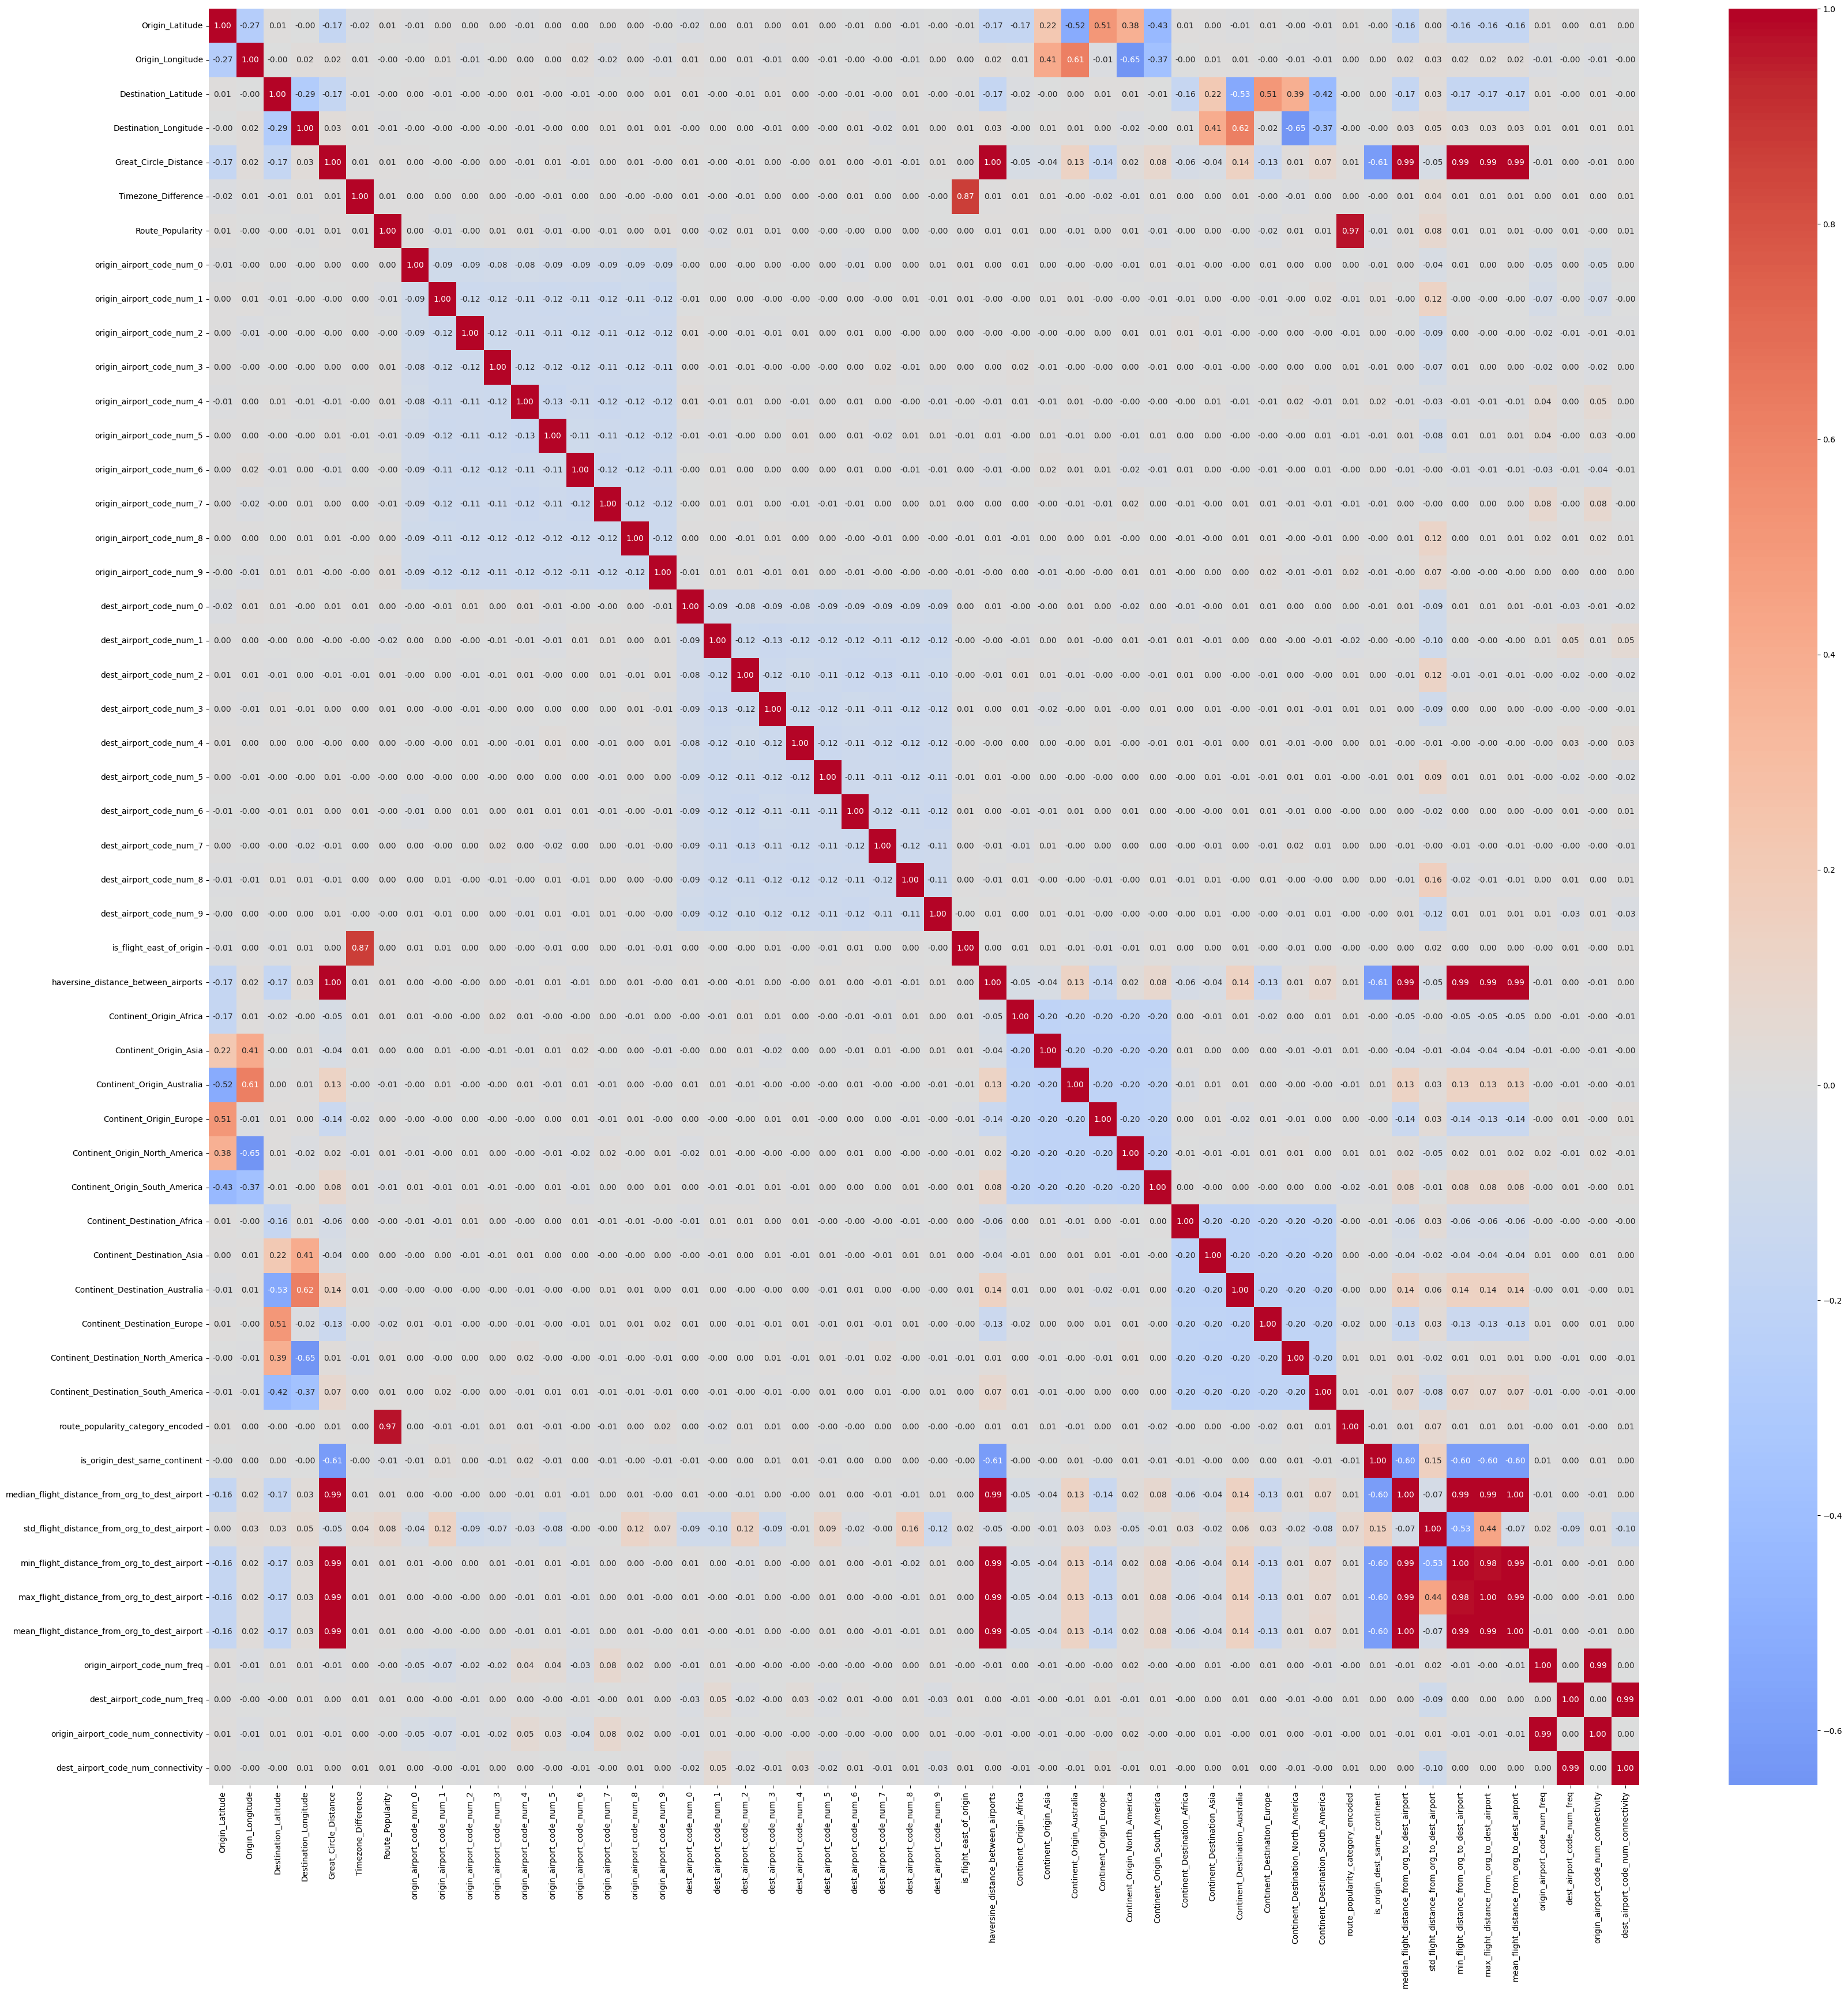

In [110]:
plt.figure(figsize=(40, 40))
sns.heatmap(train_df[feature_to_use].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.show()

In [111]:
feature_to_use.remove('haversine_distance_between_airports')
feature_to_use.remove('is_flight_east_of_origin')
feature_to_use.remove('is_origin_dest_same_continent')
feature_to_use.remove('origin_airport_code_num_connectivity')
feature_to_use.remove('dest_airport_code_num_connectivity')

In [112]:
X_train = train_df[feature_to_use]
X_test = test_df[feature_to_use]
y_train = train_df['Flight_Distance']
y_test = test_df['Flight_Distance']

In [113]:
from sklearn.model_selection import train_test_split

In [114]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [115]:
X_train.shape, X_val.shape, y_train.shape, y_val.shape

((15840, 47), (3960, 47), (15840,), (3960,))

In [116]:
import matplotlib.pyplot as plt

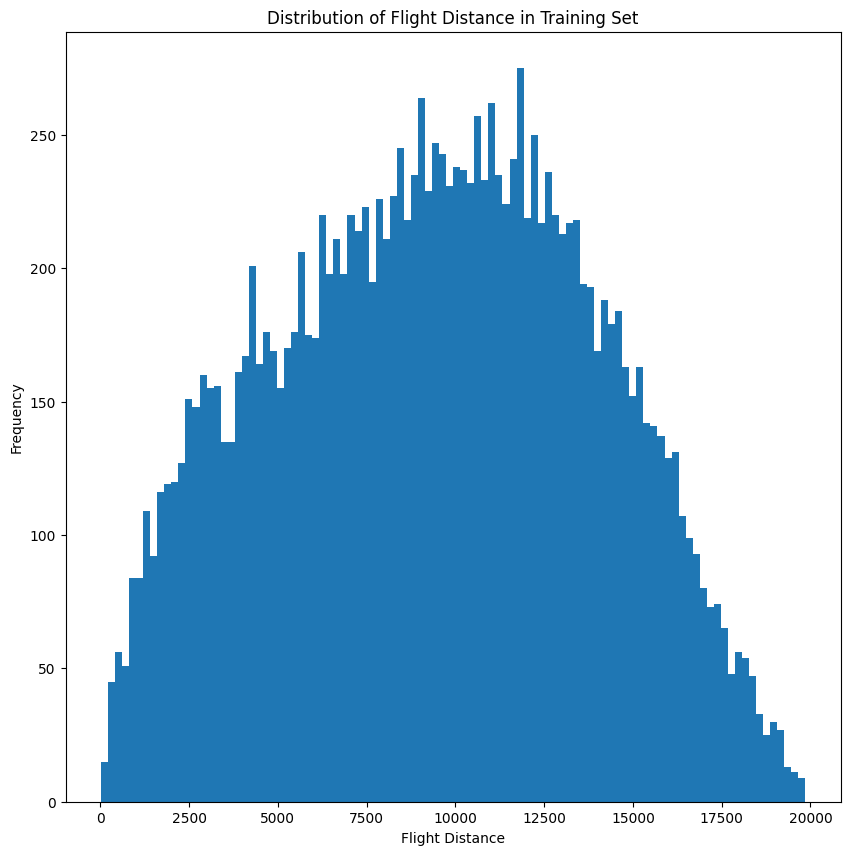

In [117]:
plt.figure(figsize=(10, 10))
plt.hist(y_train, bins=100)
plt.xlabel('Flight Distance')
plt.ylabel('Frequency')
plt.title('Distribution of Flight Distance in Training Set')
plt.show()

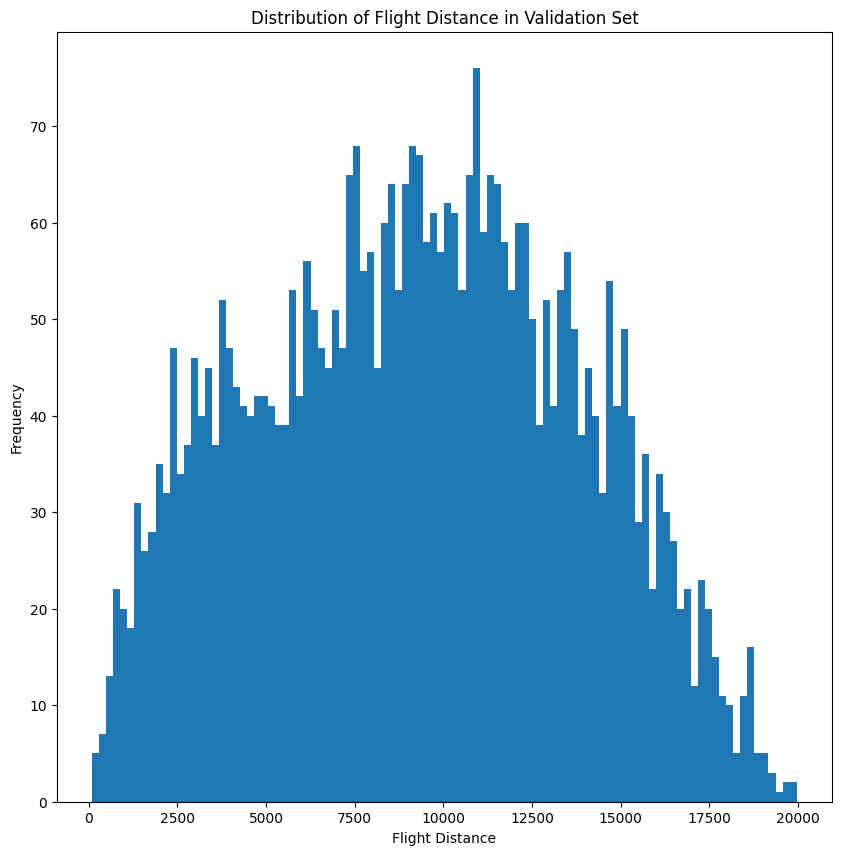

In [118]:
plt.figure(figsize=(10, 10))
plt.hist(y_val, bins=100)
plt.xlabel('Flight Distance')
plt.ylabel('Frequency')
plt.title('Distribution of Flight Distance in Validation Set')
plt.show()

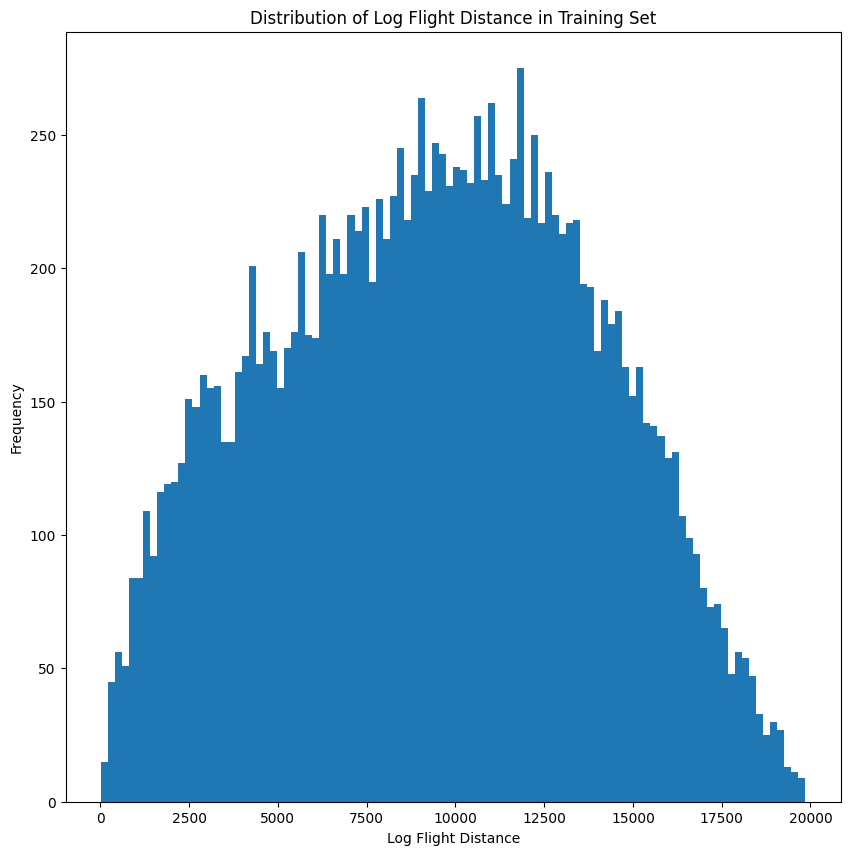

In [119]:
plt.figure(figsize=(10, 10))
plt.hist(y_train, bins=100)
plt.xlabel('Log Flight Distance')
plt.ylabel('Frequency')
plt.title('Distribution of Log Flight Distance in Training Set')
plt.show()

In [120]:
xgb_params = {
    'objective': 'reg:squarederror',
    'learning_rate': 0.1,
    'max_depth': 3,
    'subsample': 1,
    'colsample_bytree': 1,
    'seed': 42,
    'eval_metric': ['rmse', 'mae'],
    'lambda': 1,
    'alpha': 0.1,
}

In [121]:
xgb_train = xgb.DMatrix(X_train, label=y_train, enable_categorical=True)
xgb_val = xgb.DMatrix(X_val, label=y_val, enable_categorical=True)
xgb_test = xgb.DMatrix(X_test, enable_categorical=True)

In [123]:
xgb_model = xgb.train(xgb_params, xgb_train, evals=[(xgb_train, 'train'), (xgb_val, 'val')], num_boost_round=5000, verbose_eval=10,
                      early_stopping_rounds=20)

[0]	train-rmse:4032.45798	train-mae:3368.02414	val-rmse:4019.35777	val-mae:3350.86177
[10]	train-rmse:1452.09473	train-mae:1187.54919	val-rmse:1442.27360	val-mae:1179.88761
[20]	train-rmse:529.55115	train-mae:422.80461	val-rmse:521.79239	val-mae:418.66588
[30]	train-rmse:200.80082	train-mae:154.78634	val-rmse:196.17234	val-mae:152.77915
[40]	train-rmse:89.03767	train-mae:66.42162	val-rmse:87.66298	val-mae:65.48048
[50]	train-rmse:58.75920	train-mae:44.57033	val-rmse:59.30499	val-mae:44.83462
[60]	train-rmse:53.06419	train-mae:40.82070	val-rmse:54.24669	val-mae:41.49519
[70]	train-rmse:51.70049	train-mae:39.95811	val-rmse:53.11291	val-mae:40.74767
[80]	train-rmse:50.55356	train-mae:39.21052	val-rmse:52.14303	val-mae:40.01572
[90]	train-rmse:49.79814	train-mae:38.71399	val-rmse:51.58975	val-mae:39.60490
[100]	train-rmse:49.09649	train-mae:38.23002	val-rmse:51.10241	val-mae:39.18322
[110]	train-rmse:48.81285	train-mae:38.06476	val-rmse:51.05921	val-mae:39.09432
[120]	train-rmse:48.60384	t

In [124]:
xgb_model.best_iteration

4228

In [125]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, median_absolute_error

In [126]:
y_val_pred = xgb_model.predict(xgb_val)
y_test_pred = xgb_model.predict(xgb_test)

In [127]:
y_train_pred = xgb_model.predict(xgb_train)

In [128]:
y_train_pred = xgb_model.predict(xgb_train)

In [129]:
mean_absolute_error(y_val, y_val_pred), mean_squared_error(y_val, y_val_pred, squared=False), median_absolute_error(y_val, y_val_pred)

/Users/priyanshu.tuli/Desktop/machinehack/.venv/lib/python3.9/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


(16.067018420710404, 29.323081146393257, 11.027135640625147)

In [130]:
mean_absolute_error(y_train, y_train_pred), mean_squared_error(y_train, y_train_pred, squared=False), median_absolute_error(y_train, y_train_pred)

/Users/priyanshu.tuli/Desktop/machinehack/.venv/lib/python3.9/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


(9.2664502376326, 12.15468689231068, 7.319358507812467)

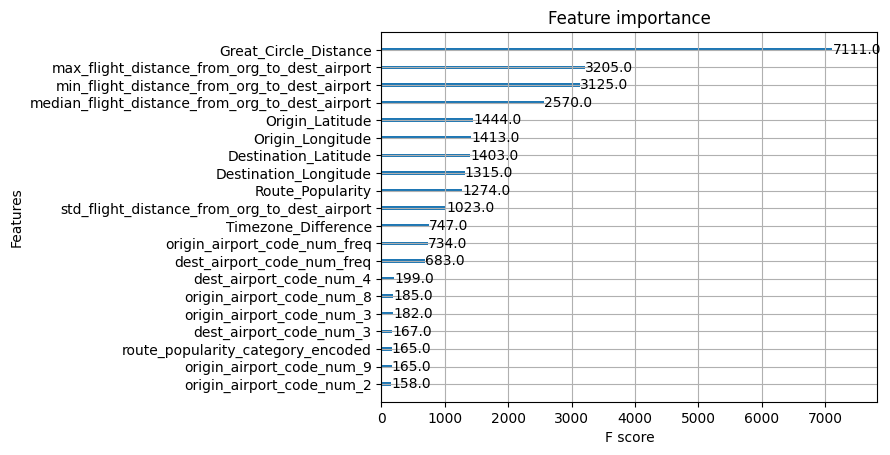

In [131]:
xgb.plot_importance(xgb_model, importance_type='weight', max_num_features=20)
plt.show()

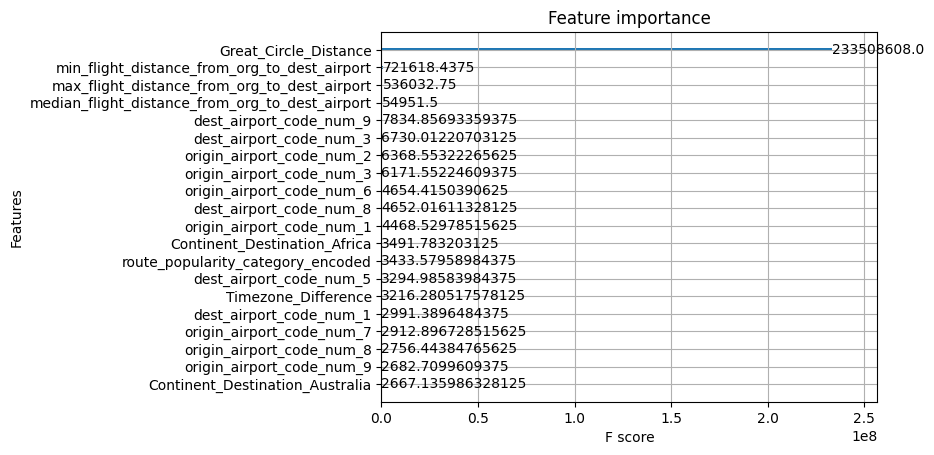

In [132]:
xgb.plot_importance(xgb_model, importance_type='gain', max_num_features=20)
plt.show()

In [133]:
train_df[['haversine_distance_between_airports', 'Great_Circle_Distance']].corr(method='pearson').round(2)

,haversine_distance_between_airports,Great_Circle_Distance
haversine_distance_between_airports,1.0,1.0
Great_Circle_Distance,1.0,1.0


In [134]:
top_features_df = pd.DataFrame({'feature': xgb_model.get_score(importance_type='weight').keys(), 'importance': xgb_model.get_score(importance_type='weight').values()})

In [135]:
top_features_df.head()

,feature,importance
0,Origin_Latitude,1444.0
1,Origin_Longitude,1413.0
2,Destination_Latitude,1403.0
3,Destination_Longitude,1315.0
4,Great_Circle_Distance,7111.0


In [136]:
top_features_df = top_features_df.sort_values(by='importance', ascending=False).reset_index(drop=True)

In [137]:
top_features_df.head()

,feature,importance
0,Great_Circle_Distance,7111.0
1,max_flight_distance_from_org_to_dest_airport,3205.0
2,min_flight_distance_from_org_to_dest_airport,3125.0
3,median_flight_distance_from_org_to_dest_airport,2570.0
4,Origin_Latitude,1444.0


In [139]:
top_features_df['normalized_importance'] = top_features_df['importance'] / top_features_df['importance'].sum()
top_features_df['normalized_importance'] = top_features_df['normalized_importance'].round(4)

In [141]:
top_features_df['cumulative_importance'] = top_features_df['normalized_importance'].cumsum()

In [142]:
top_features_df['cumulative_importance'].head()

0    0.2423
1    0.3515
2    0.4580
3    0.5456
4    0.5948
Name: cumulative_importance, dtype: float64

In [143]:
top_features_df.shape

(46, 4)

In [144]:
top_features = top_features_df[top_features_df['cumulative_importance'] <= 0.95]['feature'].tolist()

In [145]:
len(top_features)

24

In [146]:
top_features_df.shape

(46, 4)

In [147]:
X_train = train_df[top_features]
X_test = test_df[top_features]
y_train = train_df['Flight_Distance']

In [148]:
xgb_train_full = xgb.DMatrix(X_train, label=y_train, enable_categorical=True)
xgb_test_full = xgb.DMatrix(X_test, enable_categorical=True)

In [160]:
xgb_model_full_params = {
    'objective': 'reg:squarederror',
    'learning_rate': 0.1,
    'max_depth': 3,
    'subsample': 1,
    'colsample_bytree': 1,
    'seed': 42,
    'eval_metric': ['rmse', 'mae'],
    'lambda': 1,
    'alpha': 0.1,
    'verbose': 1
}
xgb_model_full = xgb.train(xgb_model_full_params, xgb_train_full, num_boost_round=500)

/Users/priyanshu.tuli/Desktop/machinehack/.venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [14:37:05] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "verbose" } are not used.

  warnings.warn(smsg, UserWarning)


In [161]:
test_preds = xgb_model_full.predict(xgb_test_full)

In [162]:
train_preds = xgb_model_full.predict(xgb_train_full)

In [163]:
train_preds

array([ 8103.376 ,  6048.7163, 18171.377 , ...,  1082.9874,  2099.8987,
       10135.211 ], dtype=float32)

In [164]:
xgb_model.best_iteration

4228

In [165]:
mean_absolute_error(y_train, train_preds), mean_squared_error(y_train, train_preds, squared=False), median_absolute_error(y_train, train_preds)

/Users/priyanshu.tuli/Desktop/machinehack/.venv/lib/python3.9/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


(27.6111733121265, 35.84580750377811, 22.704133867187466)

In [166]:
min(train_actual), max(train_actual), min(train_preds), max(train_preds)

(12.37440363, 19963.92153, 182.7039, 19616.191)

In [167]:
min(test_preds), max(test_preds)

(2805.8877, 19276.379)

In [158]:
submission_df = pd.DataFrame({'Flight_Distance': test_preds})

In [159]:
submission_df.to_csv('/Users/priyanshu.tuli/Desktop/machinehack/filght_distance_prediction/Dataset/submission.csv', index=True)

In [1191]:
from sklearn.cluster import KMeans

In [1192]:
top_features

['Great_Circle_Distance',
 'Origin_Longitude',
 'Origin_Latitude',
 'Route_Popularity',
 'Destination_Latitude',
 'Destination_Longitude',
 'Timezone_Difference',
 'origin_airport_code_num_9',
 'route_popularity_category_encoded',
 'origin_airport_code_num_1',
 'origin_airport_code_num_3',
 'dest_airport_code_num_7',
 'dest_airport_code_num_1',
 'dest_airport_code_num_3',
 'origin_airport_code_num_7',
 'dest_airport_code_num_6',
 'origin_airport_code_num_4',
 'origin_airport_code_num_5',
 'dest_airport_code_num_2',
 'origin_airport_code_num_6',
 'dest_airport_code_num_8']

In [1193]:
X_train = train_df[feature_to_use]
X_test = test_df[feature_to_use]
y_train = train_df['Flight_Distance']

In [1194]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [1229]:
kmeans = KMeans(n_clusters=50, random_state=42)

In [1230]:
y_train_kmeans = kmeans.fit_predict(y_train.values.reshape(-1, 1))
y_val_kmeans = kmeans.predict(y_val.values.reshape(-1, 1))

In [1231]:
xgb_train_kmeans = xgb.DMatrix(X_train, label=y_train_kmeans, enable_categorical=True)
xgb_val_kmeans = xgb.DMatrix(X_val, label=y_val_kmeans, enable_categorical=True)
xgb_test_kmeans = xgb.DMatrix(X_test, enable_categorical=True)

In [1232]:
xgb_classifer_params = {
    'objective': 'multi:softmax',
    'num_class': kmeans.n_clusters,
    'learning_rate': 0.1,
    'max_depth': 3,
    'subsample': 1,
    'colsample_bytree': 1,
    'seed': 42,
    'eval_metric': ['mlogloss'],
    'lambda': 1,
    'alpha': 0.1,
    'class_weight': 'balanced'
}

In [1233]:
xgb_model_kmeans = xgb.train(xgb_classifer_params, xgb_train_kmeans, evals=[(xgb_train_kmeans, 'train'), (xgb_val_kmeans, 'val')], num_boost_round=3000, verbose_eval=10,
                      early_stopping_rounds=20)

[0]	train-mlogloss:2.02436	val-mlogloss:2.03627


/Users/priyanshu.tuli/Desktop/machinehack/.venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [19:37:58] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "class_weight" } are not used.

  warnings.warn(smsg, UserWarning)


[10]	train-mlogloss:0.71638	val-mlogloss:0.73566
[20]	train-mlogloss:0.38507	val-mlogloss:0.40916
[30]	train-mlogloss:0.26140	val-mlogloss:0.29155
[40]	train-mlogloss:0.20746	val-mlogloss:0.24510
[50]	train-mlogloss:0.17905	val-mlogloss:0.22596
[60]	train-mlogloss:0.15935	val-mlogloss:0.21912
[70]	train-mlogloss:0.14320	val-mlogloss:0.21739
[80]	train-mlogloss:0.12933	val-mlogloss:0.21765
[90]	train-mlogloss:0.11744	val-mlogloss:0.21871
[92]	train-mlogloss:0.11524	val-mlogloss:0.21916


In [1241]:
y_val_pred_kmeans = xgb_model_kmeans.predict(xgb_val_kmeans)
y_test_pred_kmeans = xgb_model_kmeans.predict(xgb_test_kmeans)
y_train_pred_kmeans = xgb_model_kmeans.predict(xgb_train_kmeans)

In [1242]:
y_val_pred_kmeans

array([36., 44.,  6., ...,  2., 32., 27.], dtype=float32)

In [1243]:
y_val_pred_kmeans = y_val_pred_kmeans.astype(int)
y_test_pred_kmeans = y_test_pred_kmeans.astype(int)
y_train_pred_kmeans = y_train_pred_kmeans.astype(int)

In [1244]:
y_val.shape

(3960,)

In [1246]:
# import knn
from sklearn.neighbors import KNeighborsRegressor

In [ ]:
knn = KNeighborsRegressor(n_neighbors=5, weights='uniform', algorithm='auto', n_jobs=-1)
knn.fit(y_train)

In [1238]:
y_val_pred_kmeans = kmeans.cluster_centers_[y_val_pred_kmeans]
y_test_pred_kmeans = kmeans.cluster_centers_[y_test_pred_kmeans]
y_train_pred_kmeans = kmeans.cluster_centers_[y_train_pred_kmeans]

In [1239]:
mean_absolute_error(y_val, y_val_pred_kmeans), mean_squared_error(y_val, y_val_pred_kmeans, squared=False), median_absolute_error(y_val, y_val_pred_kmeans)

/Users/priyanshu.tuli/Desktop/machinehack/.venv/lib/python3.9/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


(97.2591657452398, 119.78511524567881, 89.27263254052514)

In [1240]:
mean_absolute_error(y_train, y_train_pred_kmeans), mean_squared_error(y_train, y_train_pred_kmeans, squared=False), median_absolute_error(y_train, y_train_pred_kmeans)

/Users/priyanshu.tuli/Desktop/machinehack/.venv/lib/python3.9/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


(93.5547789981678, 111.71926972852667, 88.66353621186636)